# From a logical algorithm down to Clifford + T

**Where we are.** A fault-tolerant machine cannot apply an arbitrary rotation
`Rz(θ)` — its logical instruction set is *discrete*: the Clifford group plus the
`T` gate. So the very first job of any FT compiler is to take a real algorithm,
full of continuous rotations, and **rewrite it exactly in that discrete set**,
approximating each rotation to a chosen accuracy `ε`. Nothing here depends on
whether the hardware is atoms or photons.

**The running example.** We compile a time evolution operator for a 2-qubit system under the influence of a Spin Hamiltonian. Quantum simulation of dynamics of many-body systems is an incredibly difficult computational problem that is not well understood in the far from equilibrium case.

**What this notebook establishes, step by step:**
1. The algorithm as a *logical circuit*
2. How an ideal evolution `e^{-iHt}` becomes a *circuit* (Trotterization) — and where
   the arbitrary rotations come from;
3. The **synthesis problem**: `Rz(θ) → Clifford+T`, solved optimally by
   `pygridsynth` (the real Ross–Selinger algorithm);
4. The cost law **`T-count ≈ 3·log₂(1/ε)`**, measured directly;
5. The **total `T`-budget** of the whole algorithm — the number notebook 02 then
   attacks.
6. **Pauli-Based Computation (PBC).** Commute every Clifford to the end of the circuit. What remains is a **sequence of Pauli rotations** `exp(-iθ/2 · P)` about multi-qubit Pauli operators `P`. Each non-Clifford (`π/8`, i.e. `T`) rotation is then performed by **measuring `P` jointly with a magic state** and applying a Clifford correction that is itself commuted onward. The algorithm becomes a **stream of multi-qubit Pauli-product measurements**, one per `T`.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import mpmath as mp
from collections import Counter

import pyzx as zx, pygridsynth
import qiskit, stim
from qiskit import QuantumCircuit, transpile, qasm2
from qiskit.quantum_info import SparsePauliOp, Statevector, Operator
from qiskit.circuit.library import PauliEvolutionGate, QFTGate
from qiskit.synthesis import LieTrotter
from scipy.linalg import expm

def is_clifford_angle(a, tol=1e-7):
    r = (float(a) / (np.pi/2)) % 1.0
    return min(r, 1 - r) < tol

def synth_T(angle, eps=mp.mpf('1e-6')):
    "T-count of the optimal Clifford+T word for Rz(angle)."
    return pygridsynth.gridsynth_gates(mp.mpf(repr(float(angle % (2*np.pi)))), eps).count('T')

from importlib.metadata import version
mp.mp.dps = 50  # high precision for the number-theoretic synthesizer
print("pyzx", version("pyzx"), "| pygridsynth", version("pygridsynth"))
print("qiskit", qiskit.__version__, "| pygridsynth", version("pygridsynth"), "| stim", stim.__version__)

pyzx 0.10.4 | pygridsynth 2.0.0
qiskit 2.5.0 | pygridsynth 2.0.0 | stim 1.16.0


## 1 · Hamiltonian

In a minimal basis, after tapering off symmetries, the electronic Hamiltonian of
H₂ near its equilibrium bond length is a **2-qubit operator** — a weighted sum of
Pauli strings (illustrative coefficients from O'Malley *et al.*, *PRX* 2016):

$$H = g_0\,II + g_1\,IZ + g_2\,ZI + g_3\,ZZ + g_4\,XX + g_5\,YY .$$

The *goal of the algorithm* is the ground-state energy `E₀` — the smallest
eigenvalue of `H`. Classically we can just diagonalise the 4×4 matrix to get the
answer we are trying to reproduce quantumly; that is our **reference**.

In [2]:
# H2 Hamiltonian as a sum of Pauli strings (2-qubit tapered, ~equilibrium geometry).
terms = {"II": -0.4804, "IZ": 0.3435, "ZI": -0.4347, "ZZ": 0.5716, "XX": 0.0910, "YY": 0.0910}
H = SparsePauliOp(list(terms), coeffs=list(terms.values()))
Hm = H.to_matrix()

evals, evecs = np.linalg.eigh(Hm)
E0 = evals.min()
ground = evecs[:, np.argmin(evals)]
print("Hamiltonian terms:", terms)
print("exact spectrum   :", np.round(evals, 4))
print(f"reference ground-state energy E0 = {E0:.4f} Hartree")

Hamiltonian terms: {'II': -0.4804, 'IZ': 0.3435, 'ZI': -0.4347, 'ZZ': 0.5716, 'XX': 0.091, 'YY': 0.091}
exact spectrum   : [-1.8512 -0.2528  0.      0.1824]
reference ground-state energy E0 = -1.8512 Hartree


## 2 · From an ideal `e^{-iHt}` to a *circuit*: Trotterization

`H` is a sum of non-commuting Pauli terms, so we cannot exponentiate it directly.
The standard move is the **Trotter–Suzuki** approximation,

$$e^{-iHt} \;\approx\; \Big(\prod_k e^{-i\,c_k P_k\, t/r}\Big)^{r},$$

turning the evolution into a product of **single-Pauli exponentials**
`e^{-i c_k P_k τ}`. Each of *those* has a fixed circuit template:

- **basis change** — rotate every qubit in `P_k`'s support so `P_k → Z…Z`
  (`H` for an `X`, `S†H` for a `Y`; nothing for a `Z`);
- **CNOT ladder** — copy the parity of the support onto one qubit;
- **`Rz(2 c_k τ)`** on that qubit — *this is the arbitrary-angle rotation*;
- **uncompute** the ladder and basis change.

So the angle of every rotation is literally a **Hamiltonian coefficient** (times
the time step). Let us build one Trotter step and look.

In [3]:
step = QuantumCircuit(2)
step.append(PauliEvolutionGate(H, time=0.5, synthesis=LieTrotter(reps=1)), [0, 1])
decomposed = step.decompose(reps=3)
print("one Trotter-step, gate counts:", dict(Counter(i.operation.name for i in decomposed.data)))

# verify the circuit really is e^{-iH t} to first order
U_trot  = Operator(decomposed).data
U_exact = expm(-1j * Hm * 0.5)
phi = np.vdot(U_trot.ravel(), U_exact.ravel()); phi /= abs(phi)
print(f"Trotter(reps=1) vs exact e^-iHt, operator distance: {np.linalg.norm(U_trot - phi*U_exact):.3f}")
print("(shrinks as O(t^2/r); more Trotter steps -> smaller error, more rotations)")

one Trotter-step, gate counts: {'u': 6, 'cx': 6, 'p': 3, 's': 4, 'h': 4, 'sdg': 4}
Trotter(reps=1) vs exact e^-iHt, operator distance: 0.049
(shrinks as O(t^2/r); more Trotter steps -> smaller error, more rotations)


### 2.1 Isolating the rotations hardware cannot do

Transpile the step into a **Clifford + `Rz`** basis and pick out the `Rz` angles.
A rotation is *free* (a Clifford) only if its angle is a multiple of `π/2`
(`Rz(π/2)=S`, `Rz(π)=Z`); any other angle is **non-Clifford** and must be
synthesised. For H₂ those angles are exactly the Hamiltonian coefficients.

In [4]:
def is_clifford_angle(a, tol=1e-9):
    r = (float(a) / (np.pi/2)) % 1.0
    return min(r, 1 - r) < tol

basis = transpile(step, basis_gates=['cx','h','s','sdg','rz','x','z'], optimization_level=1)
rz_angles = [float(i.operation.params[0]) for i in basis.data if i.operation.name == 'rz']
nonclifford = [a for a in rz_angles if not is_clifford_angle(a)]
print(f"Rz gates in one step: {len(rz_angles)}   of which non-Clifford: {len(nonclifford)}")
print("non-Clifford angles :", np.round(nonclifford, 4), " <- Hamiltonian coefficients")

Rz gates in one step: 5   of which non-Clifford: 5
non-Clifford angles : [ 0.3435 -0.4347  0.5716  0.091   0.091 ]  <- Hamiltonian coefficients


## 3 · The synthesis problem: `Rz(θ) → Clifford + T`

We must replace each such `Rz(θ)` by a *word* in `{H, S, T}` whose unitary is within
`ε` of `Rz(θ)`. This was, for a decade, done with Solovay–Kitaev (§5). In 2014
**Ross & Selinger** showed the problem is *number-theoretic* and gave an algorithm
that finds a **provably (near-)optimal** word in milliseconds. `pygridsynth` is a
direct implementation; we use it as the real tool it is.

`gridsynth_gates(θ, ε)` returns the word as a string over `{H, S, T, W}` (`W = ω =
e^{iπ/4}` is a global phase). Let's synthesise one rotation and **verify it**.

In [5]:
GATE = {'H': np.array([[1,1],[1,-1]],complex)/np.sqrt(2),
        'S': np.array([[1,0],[0,1j]],complex),
        'T': np.array([[1,0],[0,np.exp(1j*np.pi/4)]],complex),
        'X': np.array([[0,1],[1,0]],complex),
        'Y': np.array([[0,-1j],[1j,0]],complex),
        'Z': np.array([[1,0],[0,-1]],complex),
        'I': np.eye(2, dtype=complex)}

def word_to_unitary(word):
    "Map a gridsynth {H,S,T,W} word to its 2x2 unitary (W = global phase omega)."
    U = np.eye(2, dtype=complex); phase = 1.0
    for ch in reversed(word):                 # string order = matrix product order
        if ch == 'W':
            phase *= np.exp(1j*np.pi/4)
        else:
            U = GATE[ch] @ U
    return phase * U

def op_distance_upto_phase(A, B):
    "Operator (spectral-norm) distance between A and B, minimised over a global phase."
    tr = np.trace(B.conj().T @ A)          # optimal-phase alignment (Frobenius optimum)
    ph = tr/abs(tr) if abs(tr) > 1e-15 else 1.0
    return np.linalg.norm(A - ph*B, 2)

theta = 0.3435                                  # the IZ coefficient
eps = mp.mpf('1e-10')
word = pygridsynth.gridsynth_gates(mp.mpf(repr(theta)), eps)
Rz = np.array([[np.exp(-1j*theta/2), 0], [0, np.exp(1j*theta/2)]], complex)
achieved = op_distance_upto_phase(word_to_unitary(word), Rz)
print(f"Rz({theta}) at eps=1e-10:")
print(f"  word length {len(word)},  T-count {word.count('T')}")
print(f"  achieved error {achieved:.2e}  (target {float(eps):.0e})  -> {'OK' if achieved<float(eps) else 'FAIL'}")
print(f"  word head: {word[:60]}...")

Rz(0.3435) at eps=1e-10:
  word length 267,  T-count 102
  achieved error 3.36e-11  (target 1e-10)  -> OK
  word head: SHTSHTSHTHTHTHTHTSHTSHTSHTSHTSHTHTSHTSHTHTSHTSHTSHTSHTHTHTSH...


## 4 · The cost law: `T-count ≈ 3·log₂(1/ε)`

`T` is the expensive resource (each `T` costs a distilled magic state — notebook
05), so the number that matters is the **`T`-count** of a synthesised rotation, and
how it grows as we demand more accuracy. Ross–Selinger predicts

$$\text{T-count} \;\approx\; 3\log_2(1/\varepsilon) + O(\log\log 1/\varepsilon).$$

Sweep `ε` and read the slope directly off `pygridsynth`.

eps=1e-k  ->  T-count: {2: 22, 3: 34, 4: 44, 5: 54, 6: 68, 7: 76, 8: 82, 9: 96, 10: 102, 11: 114, 12: 126}
fit: T-count = 3.04 * log2(1/eps) + 3.6   (Ross-Selinger: slope 3)


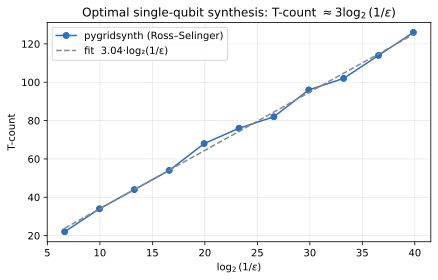

In [6]:
ks = list(range(2, 13))
Ts = []
for k in ks:
    w = pygridsynth.gridsynth_gates(mp.mpf(repr(theta)), mp.power(10, -k))
    Ts.append(w.count('T'))
x = np.array(ks) * np.log2(10)                  # log2(1/eps)
slope, intercept = np.polyfit(x, Ts, 1)
print("eps=1e-k  ->  T-count:", dict(zip(ks, Ts)))
print(f"fit: T-count = {slope:.2f} * log2(1/eps) + {intercept:.1f}   (Ross-Selinger: slope 3)")

fig, ax = plt.subplots(figsize=(6.2, 4))
ax.plot(x, Ts, 'o-', color='#2c6fbb', label='pygridsynth (Ross–Selinger)')
ax.plot(x, slope*x + intercept, '--', color='#888', label=f'fit  {slope:.2f}·log₂(1/ε)')
ax.set_xlabel(r'$\log_2(1/\varepsilon)$'); ax.set_ylabel('T-count')
ax.set_title(r'Optimal single-qubit synthesis: T-count $\approx 3\log_2(1/\varepsilon)$')
ax.legend(); ax.grid(alpha=.3); plt.tight_layout(); plt.show()

## 5 · State of the art: ZX-calculus T-count reduction (`pyzx`)

`pyzx` turns the circuit into a ZX-diagram, runs `full_reduce` (a fixed set of
sound graph rewrites — spider fusion, local complementation, pivoting — that
provably preserve the linear map), and extracts a circuit back out. It optimises
`T`-phases globally, across Hadamards. We run it on QPE(H₂), **verify the reduced
circuit is the same unitary**, and re-synthesise the survivors to get the new
T-budget.

ZX full_reduce preserves the unitary: True

non-Clifford rotations : 5  ->  5
TOTAL T-count (eps=1e-6): 314  ->  314   (0% saved)


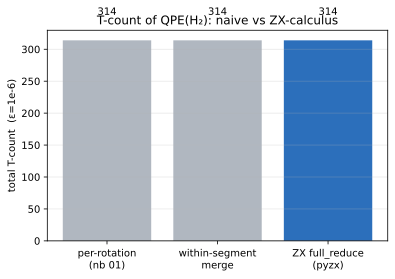

In [7]:
circ = zx.Circuit.from_qasm(qasm2.dumps(basis))
g = circ.to_graph()
zx.simplify.full_reduce(g)
reduced = zx.extract_circuit(g.copy())

print("ZX full_reduce preserves the unitary:", circ.verify_equality(reduced))

def nonclifford_angles(zxcirc):
    out = []
    for gate in zxcirc.gates:
        ph = getattr(gate, 'phase', None)
        if ph is not None:
            a = float(ph) * np.pi          # pyzx phases are in units of pi
            if not is_clifford_angle(a): out.append(a)
    return out

before = nonclifford_angles(circ)
after  = nonclifford_angles(reduced)
T_before = sum(synth_T(a) for a in before)
T_after  = sum(synth_T(a) for a in after)
print(f"\nnon-Clifford rotations : {len(before)}  ->  {len(after)}")
print(f"TOTAL T-count (eps=1e-6): {T_before}  ->  {T_after}   "
      f"({100*(T_before-T_after)/T_before:.0f}% saved)")

fig, ax = plt.subplots(figsize=(5.6, 4))
ax.bar(['per-rotation\n(nb 01)', 'within-segment\nmerge', 'ZX full_reduce\n(pyzx)'],
       [T_before, T_before, T_after], color=['#b0b7c0','#b0b7c0','#2c6fbb'])
ax.set_ylabel('total T-count  (ε=1e-6)')
ax.set_title('T-count of QPE(H₂): naive vs ZX-calculus')
for i, v in enumerate([T_before, T_before, T_after]):
    ax.text(i, v + 40, str(v), ha='center')
ax.grid(axis='y', alpha=.3); plt.tight_layout(); plt.show()

## 6 · Pauli Based Computation: Commuting Cliffords to the end

The key algebraic fact: a Clifford `C` conjugates a Pauli into a Pauli, so it slides
past a Pauli rotation, only **changing the axis**:

$$C\,\exp(-i\theta P)\;=\;\exp\!\big(-i\theta\,C P C^{\dagger}\big)\,C .$$

Applying this repeatedly moves every Clifford rightward to the end. Each `π/8`
`Z`-rotation, after all the Cliffords that preceded it have been commuted through,
becomes a `π/8` rotation about a **multi-qubit Pauli** `P = A^\dagger Z_q A`, where `A`
is the Clifford accumulated up to that point. We track `A` exactly with a `stim`
tableau (Cliffords are stabiliser operations), record the Pauli for each `T`, and are
left with `U = C_{\text{final}} \cdot \prod_k \exp(-i\tfrac{\pi}{8}P_k)`.

In [8]:
PAULI = {0: np.eye(2, dtype=complex), 1: np.array([[0,1],[1,0]], complex),
         2: np.array([[0,-1j],[1j,0]], complex), 3: np.array([[1,0],[0,-1]], complex)}

def pauli_matrix(ps):
    "Dense matrix of a stim.PauliString, little-endian (qubit 0 = least significant)."
    M = np.array([[1]], complex)
    for k in range(len(ps)):
        M = np.kron(PAULI[ps[k]], M)     # qubit 0 = least significant
    return ps.sign * M

def infidelity(X, Y):
    "Phase-invariant distance 1 - |Tr(X†Y)|/d  (0 iff X = e^{iφ} Y exactly)."
    d = X.shape[0]
    return float(1 - abs(np.trace(X.conj().T @ Y)) / d)

def clifford_plus_t(gates, eps=mp.mpf('1e-6')):
    """Expand a pyzx gate list into an explicit Clifford+T gate list (name/letter, qubits).

    Two pyzx conventions matter here — both are easy to get wrong:
    - `gate.phase` is a Fraction in UNITS OF PI, so the Rz angle is float(phase)*pi.
      Missing the pi makes gridsynth synthesise the wrong rotation, and turns
      Clifford phases like S (phase = 1/2) into fake non-Clifford angles.
    - Two-qubit gates must be read via the NAMED attributes .control/.target:
      pyzx's __dict__ ordering is {'target': ..., 'control': ...} — target FIRST —
      so unpacking __dict__.values() positionally silently swaps the CNOT
      direction. CZ and SWAP are symmetric and hide the bug; the one CNOT in
      `reduced` does not.

    Each phase gate is handed to pygridsynth (up_to_phase=True: word over {H,S,T},
    no W letters; global phase is invisible to `infidelity` anyway). The *reading
    order* of the word is a non-issue for Rz targets: H, S, T are all symmetric
    matrices, so the reversed word implements U^T, and the target Rz is diagonal
    (Rz^T = Rz) — both orders approximate it equally well.
    """
    cliff_plus_T_list = []
    t_total = 0
    for gg in gates:
        ph = getattr(gg, "phase", None)
        if ph:                                   # any Z-rotation (Clifford angles come back as exact words)
            angle = float(ph) * np.pi            # pyzx phases are fractions of pi
            word = pygridsynth.gridsynth_gates(mp.mpf(repr(angle)), eps, up_to_phase=True)
            t_total += word.count('T')
            for val in word:
                cliff_plus_T_list.append((val, gg.target))
        elif ph is not None:                     # ZPhase(0) = identity — nothing to emit
            continue
        else:                                    # Clifford gate: keep name + explicit qubits
            qs = (gg.control, gg.target) if hasattr(gg, 'control') else (gg.target,)
            cliff_plus_T_list.append((gg.name, *qs))
    return cliff_plus_T_list, t_total

def pbc_extract(gates, n):
    "Return (rotations, C_final) for a Clifford+T gate list. Each rotation is (stim.PauliString, angle)."
    A = stim.Tableau(n)                          # Clifford accumulated so far, in circuit order
    named = {'HAD':'H', 'H':'H', 's':'S', 'S':'S', 'SWAP':'SWAP', 'sdg':'S_DAG',
             'x':'X', 'X':'X', 'NOT':'X', 'Z':'Z', 'z':'Z',
             'CNOT':'CX', 'cx':'CX', 'CZ':'CZ'}
    rotations = []
    for g in gates:
        if g[0] == 't' or g[0] == 'T':
            # A T on qubit q after the accumulated Clifford A slides left:
            #   T_q · A = A · exp(-i pi/8 · A† Z_q A)   (up to global phase).
            # stim's Tableau.__call__ conjugates as P -> A P A†, so the
            # pushed-through Pauli A† Z_q A is A.inverse()(Z_q).
            Zq = stim.PauliString(n); Zq[g[1]] = 3        # Z on the T's qubit
            rotations.append((A.inverse()(Zq), np.pi/4))  # theta=pi/4 in exp(-i theta/2 P) ≅ T
        elif g[0] == 'W':
            continue                              # gridsynth global phase — no stim gate, irrelevant here
        else:
            A.append(stim.Tableau.from_named_gate(named[g[0]]), list(g[1:]))
    return rotations, A

n = 2
gates, t_total = clifford_plus_t(reduced.gates)
rotations, C_final = pbc_extract(gates, n)
print(f"{len(rotations)} pi/8 Pauli rotations extracted, total T-count {t_total}")

# reconstruct U = C_final · prod_k exp(-i theta/2 P_k)  (first rotation rightmost = applied first)
prod = np.eye(2**n, dtype=complex)
for P, theta in rotations:
    prod = expm(-1j*theta/2 * pauli_matrix(P)) @ prod
U_pbc = C_final.to_unitary_matrix(endian='little') @ prod

# The honest reference is the circuit we actually compiled — the ONE Trotter step
# (`basis`); against it the only residual is the eps=1e-6 synthesis error.
# Against the exact e^{-iHt} we additionally see the O(t^2) Trotter error of §2,
# a property of the *algorithm* (reps=1), not of the compiler.
U_step = Operator(basis).data
print("PBC form vs the compiled Trotter step:  infidelity =", f"{infidelity(U_pbc, U_step):.3e}")
print("PBC form vs the exact e^-iHt         :  infidelity =", f"{infidelity(U_pbc, U_exact):.3e}",
      " <- Trotter error (shrinks with reps)")

314 pi/8 Pauli rotations extracted, total T-count 314
PBC form vs the compiled Trotter step:  infidelity = 4.543e-13
PBC form vs the exact e^-iHt         :  infidelity = 3.025e-04  <- Trotter error (shrinks with reps)
